In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Configuración visual para las gráficas
sns.set_theme(style="whitegrid")

In [4]:
# Cargar los datos de los archivos JSON
with open('../data/contexts.json', 'r', encoding='utf-8') as f:
    contexts_data = json.load(f)

with open('../data/questions_train.json', 'r', encoding='utf-8') as f:
    questions_data = json.load(f)

# Convertir a DataFrames de Pandas
df_contexts = pd.DataFrame(contexts_data)
df_questions = pd.DataFrame(questions_data)

print("Datos de Contextos cargados. Dimensiones:", df_contexts.shape)
print("Datos de Preguntas cargados. Dimensiones:", df_questions.shape)

Datos de Contextos cargados. Dimensiones: (20233, 3)
Datos de Preguntas cargados. Dimensiones: (350, 3)


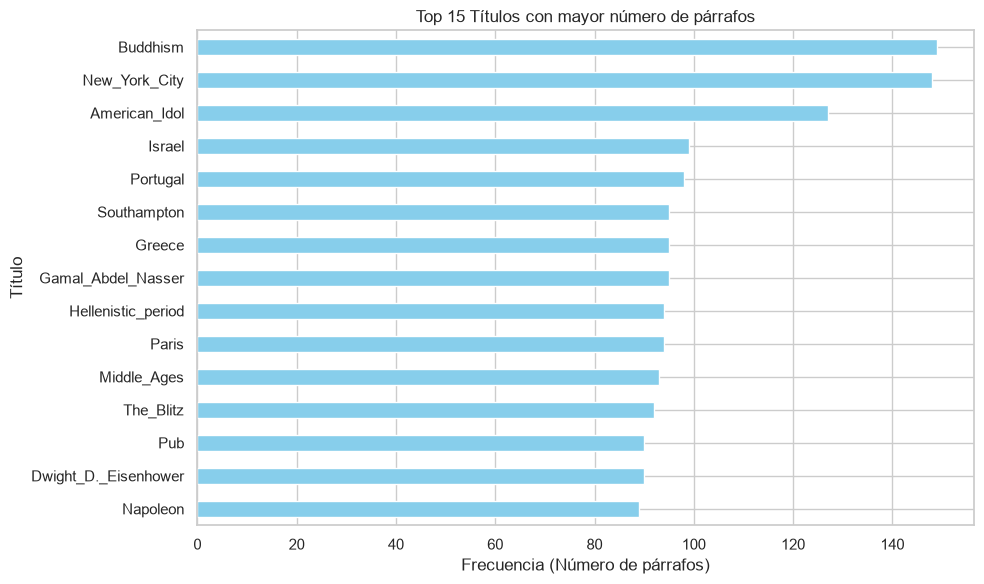

In [14]:
# Obtener solo los 15 títulos con más párrafos
top_titulos = df_contexts['title'].value_counts().head(15)

plt.figure(figsize=(10, 6))

# Usar 'barh' para barras horizontales
top_titulos.plot(kind='barh', color='skyblue')

plt.title('Top 15 Títulos con mayor número de párrafos')
plt.xlabel('Frecuencia (Número de párrafos)')
plt.ylabel('Título')

# Invertir el eje Y para que el título con más párrafos quede en la parte superior
plt.gca().invert_yaxis()

# Ajustar márgenes
plt.tight_layout()

plt.show()

In [6]:
# Mostrar las primeras filas
display(df_questions.head())

# Identificar valores nulos (preguntas sin respuesta o sin contexto)
print("\nValores nulos en questions_train.json:")
print(df_questions.isnull().sum())

# Filtrar las preguntas que no tienen contexto/respuesta
preguntas_nulas = df_questions[df_questions['answer'].isnull()]
print(f"\nHay {len(preguntas_nulas)} preguntas que no tienen respuesta ni contexto asociado.")

,question,answer,context
0,In what region are the Zagorci found?,northern Croatia,c03782
1,"Who wrote that Baptists called themselves ""the...",McBeth,c11209
2,When did Tito introduce the self-management sy...,1951,c03951
3,Is that the one you meant?,NaN,NaN
4,Which railway opened beneath central London in...,Elizabeth line,NaN



Valores nulos en questions_train.json:
question      0
answer       50
context     100
dtype: int64

Hay 50 preguntas que no tienen respuesta ni contexto asociado.


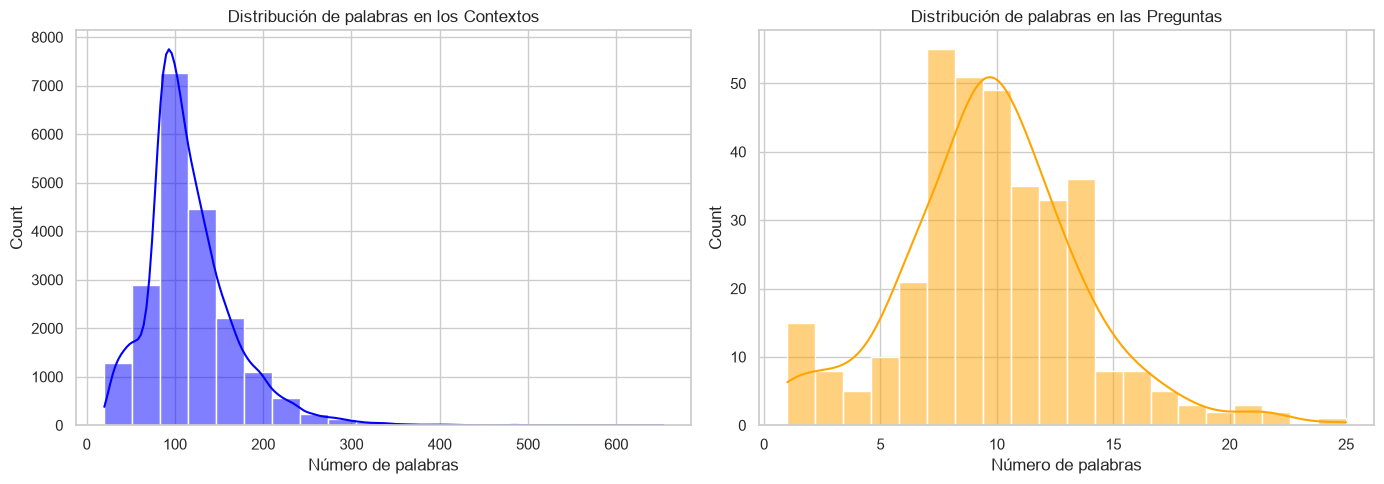

In [7]:
# Calcular la longitud (en número de palabras) de los textos y preguntas
df_contexts['text_word_count'] = df_contexts['text'].apply(lambda x: len(str(x).split()))
df_questions['question_word_count'] = df_questions['question'].apply(lambda x: len(str(x).split()))

# Graficar la distribución de longitudes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_contexts['text_word_count'], bins=20, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribución de palabras en los Contextos')
axes[0].set_xlabel('Número de palabras')

sns.histplot(df_questions['question_word_count'], bins=20, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribución de palabras en las Preguntas')
axes[1].set_xlabel('Número de palabras')

plt.tight_layout()
plt.show()

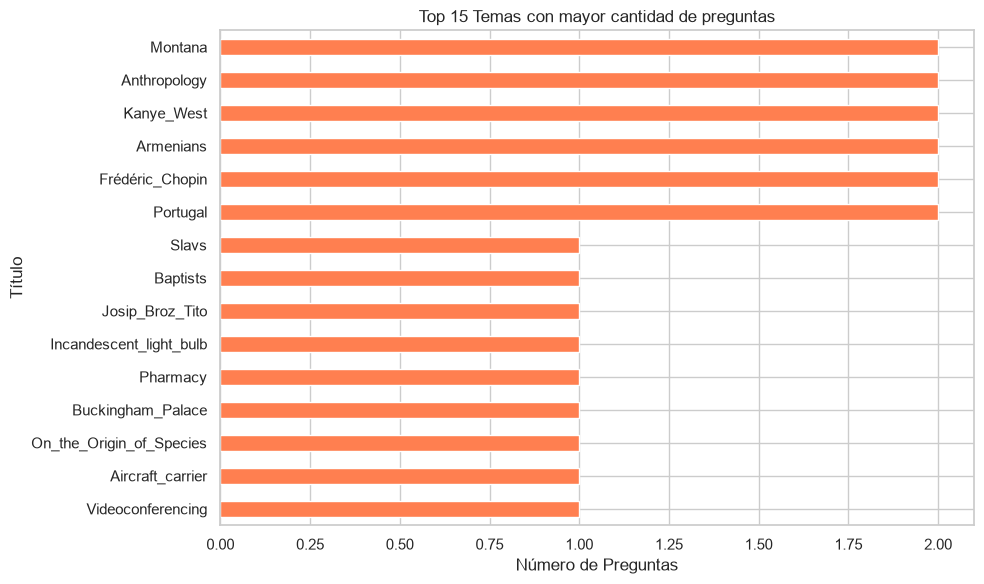

In [13]:
# Obtener solo los 15 temas con más preguntas
top_temas = df_merged['title'].value_counts().head(15)

plt.figure(figsize=(10, 6))

# Usar 'barh' para barras horizontales
top_temas.plot(kind='barh', color='coral')

plt.title('Top 15 Temas con mayor cantidad de preguntas')
plt.xlabel('Número de Preguntas')
plt.ylabel('Título')

# Invertir el eje Y para que el tema con más preguntas quede en la parte superior
plt.gca().invert_yaxis() 

# Ajustar los márgenes automáticamente
plt.tight_layout()

plt.show()

Resumen de calidad y cobertura


,Métrica,Valor,Porcentaje
0,Contextos totales,20233,100.00
1,IDs de contexto únicos,20233,100.00
2,Contextos duplicados,0,0.00
3,Preguntas totales,350,100.00
4,Preguntas duplicadas,0,0.00
5,Preguntas con respuesta,300,85.71
6,Preguntas con contexto,250,71.43
7,Preguntas con respuesta y contexto,250,71.43
8,Títulos únicos,477,100.00



Distribución de longitudes (palabras)


,Variable,N,Media,Mediana,P5,P95,Máximo
0,Texto de contexto,20233,117.19,108.0,47.0,210.0,653
1,Pregunta,350,9.78,10.0,3.0,16.0,25
2,Respuesta,300,2.48,2.0,1.0,6.0,26



Balance de preguntas por título


,title,contextos,preguntas,mediana_contexto_palabras,mediana_pregunta_palabras,preguntas_por_contexto,porcentaje_preguntas
0,Armenians,2,2,131.0,7.5,1.0,0.8
1,Anthropology,2,2,110.5,9.5,1.0,0.8
2,Frédéric_Chopin,2,2,105.0,8.5,1.0,0.8
3,Kanye_West,2,2,120.0,16.0,1.0,0.8
4,Montana,2,2,88.5,8.0,1.0,0.8
...,...,...,...,...,...,...,...
239,Windows_8,1,1,274.0,10.0,1.0,0.4
240,Xbox_360,1,1,198.0,10.0,1.0,0.4
241,Yale_University,1,1,214.0,6.0,1.0,0.4
242,Zhejiang,1,1,40.0,11.0,1.0,0.4



Preguntas repetidas más frecuentes


,question_normalized,repeticiones,ejemplos



Primeros casos sin respuesta y/o contexto


,question,answer,context,has_answer,has_context
3,Is that the one you meant?,NaN,NaN,False,False
4,Which railway opened beneath central London in...,Elizabeth line,NaN,True,False
7,What text-to-image model was released by Stabi...,Stable Diffusion,NaN,True,False
11,!!,NaN,NaN,False,False
16,What game won Game of the Year at The Game Awa...,Baldur's Gate 3,NaN,True,False
17,Which country hosted the 2023 BRICS summit?,South Africa,NaN,True,False
25,...,NaN,NaN,False,False
28,Which country approved same-sex marriage in a ...,Switzerland,NaN,True,False
31,Who won Mexico's 2024 presidential election?,Claudia Sheinbaum,NaN,True,False
33,How many books are on the shelf behind me?,NaN,NaN,False,False


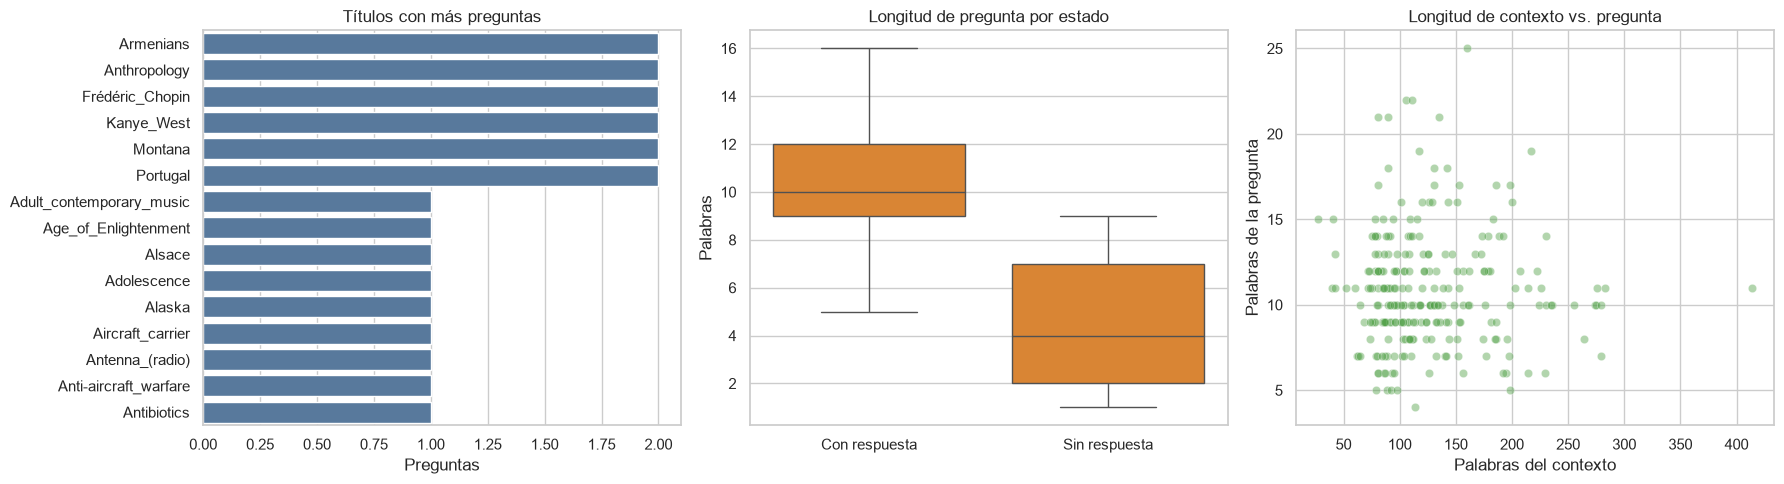


Correlación de Spearman entre longitud del contexto y de la pregunta: 0.013


In [ ]:
# Variables derivadas para el análisis de preguntas
for column in ['question_word_count']:
    if column not in df_questions:
        df_questions[column] = df_questions['question'].fillna('').astype(str).str.split().str.len()

df_questions['has_answer'] = df_questions['answer'].notna() & df_questions['answer'].astype('string').str.strip().ne('')
df_questions['has_context'] = df_questions['context'].notna() & df_questions['context'].astype('string').str.strip().ne('')
df_questions['has_answer_and_context'] = df_questions['has_answer'] & df_questions['has_context']
df_questions['answer_word_count'] = df_questions['answer'].fillna('').astype(str).str.split().str.len()
df_questions['question_normalized'] = (
    df_questions['question'].fillna('').astype(str).str.lower().str.replace(r'\\s+', ' ', regex=True).str.strip()
)

# 1. Resumen de calidad y cobertura
resumen_calidad = pd.DataFrame({
    'Métrica': [
        'Contextos totales', 'IDs de contexto únicos', 'Contextos duplicados',
        'Preguntas totales', 'Preguntas duplicadas', 'Preguntas con respuesta',
        'Preguntas con contexto', 'Preguntas con respuesta y contexto',
        'Títulos únicos'
    ],
    'Valor': [
        len(df_contexts), df_contexts['id'].nunique(), df_contexts['id'].duplicated().sum(),
        len(df_questions), df_questions['question_normalized'].duplicated(keep=False).sum(),
        int(df_questions['has_answer'].sum()), int(df_questions['has_context'].sum()),
        int(df_questions['has_answer_and_context'].sum()), df_contexts['title'].nunique()
    ]
})
resumen_calidad['Porcentaje'] = resumen_calidad['Valor'].div(
    [len(df_contexts), len(df_contexts), len(df_contexts), len(df_questions),
     len(df_questions), len(df_questions), len(df_questions), len(df_questions),
     df_contexts['title'].nunique()]
).mul(100).round(2)
print('Resumen de calidad y cobertura')
display(resumen_calidad)

# 2. Tabla de distribución de longitudes con medidas robustas
metricas_longitud = pd.DataFrame({
    'Variable': ['Texto de contexto', 'Pregunta', 'Respuesta'],
    'N': [len(df_contexts), len(df_questions), int(df_questions['has_answer'].sum())],
    'Media': [
        df_contexts['text_word_count'].mean(),
        df_questions['question_word_count'].mean(),
        df_questions.loc[df_questions['has_answer'], 'answer_word_count'].mean()
    ],
    'Mediana': [
        df_contexts['text_word_count'].median(),
        df_questions['question_word_count'].median(),
        df_questions.loc[df_questions['has_answer'], 'answer_word_count'].median()
    ],
    'P5': [
        df_contexts['text_word_count'].quantile(.05),
        df_questions['question_word_count'].quantile(.05),
        df_questions.loc[df_questions['has_answer'], 'answer_word_count'].quantile(.05)
    ],
    'P95': [
        df_contexts['text_word_count'].quantile(.95),
        df_questions['question_word_count'].quantile(.95),
        df_questions.loc[df_questions['has_answer'], 'answer_word_count'].quantile(.95)
    ],
    'Máximo': [
        df_contexts['text_word_count'].max(),
        df_questions['question_word_count'].max(),
        df_questions.loc[df_questions['has_answer'], 'answer_word_count'].max()
    ]
}).round(2)
print('\nDistribución de longitudes (palabras)')
display(metricas_longitud)

# 3. Balance temático: contexto, preguntas y densidad de preguntas
preguntas_por_titulo = df_merged.groupby('title').agg(
    contextos=('id', 'nunique'),
    preguntas=('question', 'size'),
    mediana_contexto_palabras=('text_word_count', 'median'),
    mediana_pregunta_palabras=('question_word_count', 'median')
)
preguntas_por_titulo['preguntas_por_contexto'] = (
    preguntas_por_titulo['preguntas'] / preguntas_por_titulo['contextos']
).round(2)
preguntas_por_titulo['porcentaje_preguntas'] = (
    preguntas_por_titulo['preguntas'] / len(df_merged) * 100
).round(2)
preguntas_por_titulo = preguntas_por_titulo.sort_values('preguntas', ascending=False)
print('\nBalance de preguntas por título')
display(preguntas_por_titulo.reset_index())

# 4. Preguntas repetidas y preguntas sin respuesta/contexto
preguntas_repetidas = (
    df_questions[df_questions['question_normalized'].duplicated(keep=False)]
    .groupby('question_normalized', as_index=False)
    .agg(repeticiones=('question', 'size'), ejemplos=('question', 'first'))
    .sort_values(['repeticiones', 'ejemplos'], ascending=[False, True])
    .head(10)
)
print('\nPreguntas repetidas más frecuentes')
display(preguntas_repetidas)

casos_incompletos = df_questions.loc[
    ~df_questions['has_answer_and_context'],
    ['question', 'answer', 'context', 'has_answer', 'has_context']
].head(10)
print('\nPrimeros casos sin respuesta y/o contexto')
display(casos_incompletos)

# 5. Visualizaciones adicionales para detectar desbalance y valores atípicos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=preguntas_por_titulo.head(15).reset_index(),
    y='title', x='preguntas', ax=axes[0], color='#4C78A8'
)
axes[0].set_title('Títulos con más preguntas')
axes[0].set_xlabel('Preguntas')
axes[0].set_ylabel('')

longitudes_preguntas = df_questions.copy()
longitudes_preguntas['Estado'] = longitudes_preguntas['has_answer'].map(
    {True: 'Con respuesta', False: 'Sin respuesta'}
)
sns.boxplot(
    data=longitudes_preguntas, x='Estado', y='question_word_count',
    ax=axes[1], color='#F58518', showfliers=False
)
axes[1].set_title('Longitud de pregunta por estado')
axes[1].set_xlabel('')
axes[1].set_ylabel('Palabras')

sns.scatterplot(
    data=df_merged, x='text_word_count', y='question_word_count',
    alpha=.45, ax=axes[2], color='#54A24B'
)
axes[2].set_title('Longitud de contexto vs. pregunta')
axes[2].set_xlabel('Palabras del contexto')
axes[2].set_ylabel('Palabras de la pregunta')

plt.tight_layout()
plt.show()

print(
    f"\nCorrelación de Spearman entre longitud del contexto y de la pregunta: "
    f"{df_merged[['text_word_count', 'question_word_count']].corr(method='spearman').iloc[0, 1]:.3f}"
)

Cobertura real de las preguntas


,Estado,Preguntas,Porcentaje
0,Respuesta y contexto válidos,250,71.43
1,Respuesta sin contexto válido,50,14.29
2,Contexto sin respuesta,0,0.00
3,Sin respuesta ni contexto,50,14.29



Integridad de campos


,Campo,Nulos,Cadenas vacías
0,id de contexto,0,0
1,title,0,0
2,text,0,0
3,question,0,0
4,answer,50,50
5,context,100,100



Composición por tipo de pregunta


,question_type,preguntas,con_respuesta,porcentaje,tasa_respuesta
0,Otros/no estándar,97,69,27.71,71.13
1,Entidad/definición,85,76,24.29,89.41
2,Selección,77,73,22.00,94.81
3,Persona,43,42,12.29,97.67
4,Fecha,30,28,8.57,93.33
5,Cantidad,13,9,3.71,69.23
6,Procedimiento/medida,3,3,0.86,100.0
7,Lugar,1,0,0.29,0.0
8,Sí/No,1,0,0.29,0.0



Contextos reutilizados por varias preguntas


,id,title,preguntas,respuestas,palabras_contexto


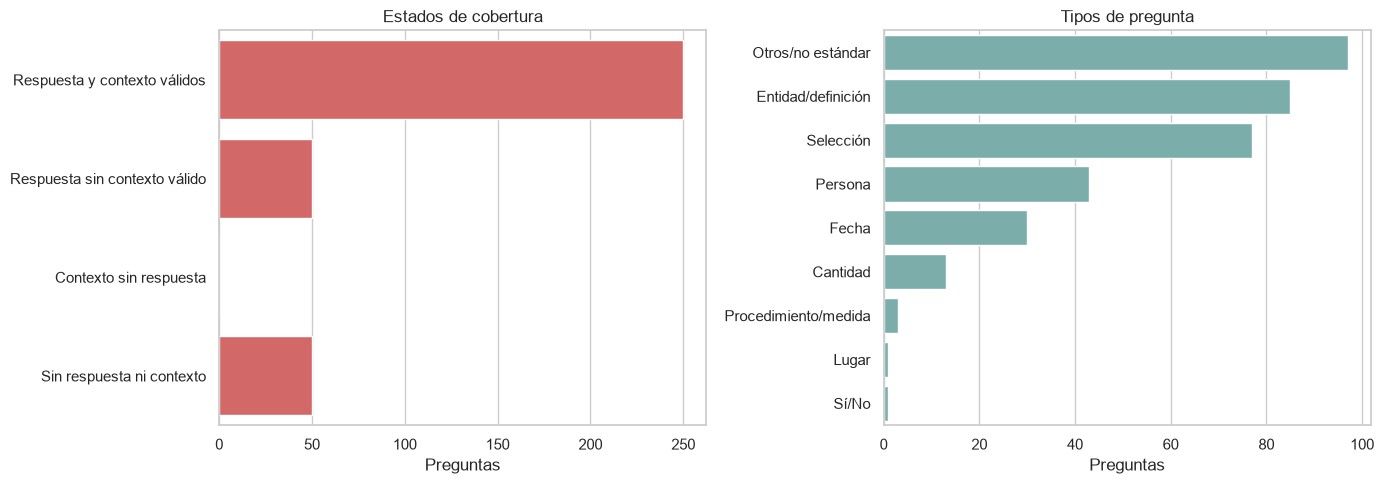

In [10]:
# Diagnóstico adicional de cobertura y composición de las preguntas
context_ids = set(df_contexts['id'].dropna())
df_questions['context_exists'] = df_questions['context'].isin(context_ids)
df_questions['coverage_status'] = 'Sin respuesta ni contexto'
df_questions.loc[df_questions['has_answer'] & ~df_questions['context_exists'], 'coverage_status'] = 'Respuesta sin contexto válido'
df_questions.loc[~df_questions['has_answer'] & df_questions['context_exists'], 'coverage_status'] = 'Contexto sin respuesta'
df_questions.loc[df_questions['has_answer'] & df_questions['context_exists'], 'coverage_status'] = 'Respuesta y contexto válidos'

orden_estados = [
    'Respuesta y contexto válidos', 'Respuesta sin contexto válido',
    'Contexto sin respuesta', 'Sin respuesta ni contexto'
]
cobertura = (
    df_questions['coverage_status'].value_counts()
    .reindex(orden_estados, fill_value=0)
    .rename_axis('Estado')
    .reset_index(name='Preguntas')
)
cobertura['Porcentaje'] = (cobertura['Preguntas'] / len(df_questions) * 100).round(2)
print('Cobertura real de las preguntas')
display(cobertura)

# Control de integridad de los campos principales
integridad = pd.DataFrame({
    'Campo': ['id de contexto', 'title', 'text', 'question', 'answer', 'context'],
    'Nulos': [
        df_contexts['id'].isna().sum(), df_contexts['title'].isna().sum(),
        df_contexts['text'].isna().sum(), df_questions['question'].isna().sum(),
        df_questions['answer'].isna().sum(), df_questions['context'].isna().sum()
    ],
    'Cadenas vacías': [
        0,
        df_contexts['title'].fillna('').astype(str).str.strip().eq('').sum(),
        df_contexts['text'].fillna('').astype(str).str.strip().eq('').sum(),
        df_questions['question'].fillna('').astype(str).str.strip().eq('').sum(),
        df_questions['answer'].fillna('').astype(str).str.strip().eq('').sum(),
        df_questions['context'].fillna('').astype(str).str.strip().eq('').sum()
    ]
})
print('\nIntegridad de campos')
display(integridad)

# Clasificación sencilla del tipo de pregunta para estudiar la composición del conjunto
question_stems = {
    'Who': 'Persona', 'What': 'Entidad/definición', 'When': 'Fecha',
    'Where': 'Lugar', 'Which': 'Selección', 'How many': 'Cantidad',
    'How much': 'Cantidad', 'How': 'Procedimiento/medida',
    'Is': 'Sí/No', 'Are': 'Sí/No', 'Did': 'Sí/No', 'Do': 'Sí/No', 'Can': 'Sí/No'
}
def classify_question(question):
    normalized = str(question).strip().lower()
    for stem, label in sorted(question_stems.items(), key=lambda item: -len(item[0])):
        if normalized.startswith(stem.lower() + ' '):
            return label
    return 'Otros/no estándar'

df_questions['question_type'] = df_questions['question'].map(classify_question)
tipos_pregunta = (
    df_questions.groupby('question_type')
    .agg(preguntas=('question', 'size'), con_respuesta=('has_answer', 'sum'))
    .assign(porcentaje=lambda table: (table['preguntas'] / len(df_questions) * 100).round(2),
            tasa_respuesta=lambda table: (table['con_respuesta'] / table['preguntas'] * 100).round(2))
    .sort_values('preguntas', ascending=False)
    .reset_index()
)
print('\nComposición por tipo de pregunta')
display(tipos_pregunta)

# Contextos que concentran más preguntas, útil para detectar reutilización o sesgo
contextos_reutilizados = (
    df_merged.groupby(['id', 'title'], as_index=False)
    .agg(preguntas=('question', 'size'),
         respuestas=('answer', lambda values: values.notna().sum()),
         palabras_contexto=('text_word_count', 'first'))
    .query('preguntas > 1')
    .sort_values(['preguntas', 'respuestas'], ascending=False)
    .head(15)
)
print('\nContextos reutilizados por varias preguntas')
display(contextos_reutilizados)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=cobertura, y='Estado', x='Preguntas', ax=axes[0], color='#E45756')
axes[0].set_title('Estados de cobertura')
axes[0].set_xlabel('Preguntas')
axes[0].set_ylabel('')

sns.barplot(data=tipos_pregunta, y='question_type', x='preguntas', ax=axes[1], color='#72B7B2')
axes[1].set_title('Tipos de pregunta')
axes[1].set_xlabel('Preguntas')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()